In [2]:
import pandas as pd
from sklearn.datasets import load_digits, make_classification
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as pl

In [3]:
dataset1 = pd.read_csv('C:/Users/Admin/Desktop/Data Mining/data_for_kdm912s_assessment_3_2025/task1Data.csv')
dataset1

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10
0,1166630,7,5,6,10,5,10,4,4,9,7
1,1166654,10,3,5,1,10,5,4,2,10,3
2,1167439,2,3,4,4,2,5,4,1,5,2
3,1167471,4,1,2,1,2,1,2,1,1,3
4,1168359,8,2,3,1,6,3,4,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...
694,1160476,2,1,1,1,2,1,2,1,1,3
695,1164066,1,1,1,1,2,1,2,1,1,3
696,1165297,2,1,1,2,2,1,2,1,1,1
697,1165790,5,1,1,1,2,1,2,1,1,3


In [4]:

dataset1.keys()


Index(['Feature0', 'Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5',
       'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10'],
      dtype='object')

In [5]:
print(dataset1.head()) # first five rows

   Feature0  Feature1  Feature2  Feature3  Feature4  Feature5 Feature6  \
0   1166630         7         5         6        10         5       10   
1   1166654        10         3         5         1        10        5   
2   1167439         2         3         4         4         2        5   
3   1167471         4         1         2         1         2        1   
4   1168359         8         2         3         1         6        3   

   Feature7  Feature8  Feature9  Feature10  
0         4         4         9          7  
1         4         2        10          3  
2         4         1         5          2  
3         2         1         1          3  
4         4         1         1          7  


In [6]:
missing = dataset1.isin(['?'])

In [7]:
print(missing)

     Feature0  Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
0       False     False     False     False     False     False     False   
1       False     False     False     False     False     False     False   
2       False     False     False     False     False     False     False   
3       False     False     False     False     False     False     False   
4       False     False     False     False     False     False     False   
..        ...       ...       ...       ...       ...       ...       ...   
694     False     False     False     False     False     False     False   
695     False     False     False     False     False     False     False   
696     False     False     False     False     False     False     False   
697     False     False     False     False     False     False     False   
698     False     False     False     False     False     False     False   

     Feature7  Feature8  Feature9  Feature10  
0       False     False     

In [8]:
missing_values = dataset1.isin(['?']).sum()
    

In [9]:
print(dataset1.dtypes)
    

Feature0      int64
Feature1      int64
Feature2      int64
Feature3      int64
Feature4      int64
Feature5      int64
Feature6     object
Feature7      int64
Feature8      int64
Feature9      int64
Feature10     int64
dtype: object


In [10]:
dataset1.replace('?', np.nan, inplace=True)
datasetms= dataset1[dataset1.isna().any(axis=1)]

In [11]:
# Convert to int64 specifically
dataset1['Feature6'] = pd.to_numeric(dataset1['Feature6'], errors='coerce').astype('int64')
dataset1.fillna(dataset1.mean(), inplace=True)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
dataset1.info()

In [12]:
dataset1.describe().round(3)

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature7,Feature8,Feature9,Feature10
count,6.990000e+02,699.000,699.000,699.000,699.000,699.000,699.000,699.000,699.000,699.000
mean,1.071704e+06,4.418,3.134,3.207,2.807,3.216,2.690,1.589,2.867,3.438
std,6.170957e+05,2.816,3.051,2.972,2.855,2.214,0.951,1.715,3.054,2.438
min,6.163400e+04,1.000,1.000,1.000,1.000,1.000,2.000,1.000,1.000,1.000
25%,8.706885e+05,2.000,1.000,1.000,1.000,2.000,2.000,1.000,1.000,2.000
50%,1.171710e+06,4.000,1.000,1.000,1.000,2.000,2.000,1.000,1.000,3.000
75%,1.238298e+06,6.000,5.000,5.000,4.000,4.000,4.000,1.000,4.000,5.000
max,1.345435e+07,10.000,10.000,10.000,10.000,10.000,4.000,10.000,10.000,10.000


In [13]:
dataset2= dataset1.drop('Feature0', axis=1)

In [14]:
print(dataset2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feature1   699 non-null    int64 
 1   Feature2   699 non-null    int64 
 2   Feature3   699 non-null    int64 
 3   Feature4   699 non-null    int64 
 4   Feature5   699 non-null    int64 
 5   Feature6   683 non-null    object
 6   Feature7   699 non-null    int64 
 7   Feature8   699 non-null    int64 
 8   Feature9   699 non-null    int64 
 9   Feature10  699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB
None


In [15]:
sdata = StandardScaler()
sdata.fit(dataset2)
scaled = sdata.fit_transform(dataset2)

In [16]:
scaled

array([[ 0.91773703,  0.61179192,  0.94032386, ...,  1.40653241,
         2.00988041,  1.46195655],
       [ 1.983939  , -0.04410156,  0.60359928, ...,  0.23956962,
         2.33759359, -0.17966213],
       [-0.85926625, -0.04410156,  0.2668747 , ..., -0.34391178,
         0.69902769, -0.5900668 ],
       ...,
       [-0.85926625, -0.69999505, -0.74329904, ..., -0.34391178,
        -0.61182504, -1.00047147],
       [ 0.20693572, -0.69999505, -0.74329904, ..., -0.34391178,
        -0.61182504, -0.17966213],
       [ 1.62853834,  0.93973866,  1.9504976 , ...,  4.9074208 ,
         2.00988041, -0.5900668 ]])

In [17]:
cov_matrix = np.cov(scaled, rowvar=False)
cov_matrix = np.round(cov_matrix, 2)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[1.   0.65 0.66 0.49 0.52  nan 0.72 0.35 0.54 0.56]
 [0.65 1.   0.91 0.71 0.75  nan 0.82 0.46 0.72 0.76]
 [0.66 0.91 1.   0.68 0.72  nan 0.82 0.44 0.72 0.74]
 [0.49 0.71 0.68 1.   0.6   nan 0.7  0.42 0.6  0.67]
 [0.52 0.75 0.72 0.6  1.    nan 0.68 0.48 0.63 0.62]
 [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [0.72 0.82 0.82 0.7  0.68  nan 1.   0.42 0.71 0.76]
 [0.35 0.46 0.44 0.42 0.48  nan 0.42 1.   0.43 0.34]
 [0.54 0.72 0.72 0.6  0.63  nan 0.71 0.43 1.   0.67]
 [0.56 0.76 0.74 0.67 0.62  nan 0.76 0.34 0.67 1.  ]]


In [18]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Round results to 2 decimal places for readability
eigenvalues = np.round(eigenvalues, 2)
eigenvectors = np.round(eigenvectors, 2)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

LinAlgError: Array must not contain infs or NaNs

In [19]:
pca = np.dot(scaled, eigenvectors)
print("\nPCA:\n", np.round(pca, 2))

NameError: name 'eigenvectors' is not defined

In [20]:
scaled.shape

(699, 10)

In [21]:
scaled.describe().round(3)

AttributeError: 'numpy.ndarray' object has no attribute 'describe'

In [22]:
pca = PCA()
pca.fit(scaled)
# Sort by eigenvalues (PCA already does this, but for consistency)
explained_variance = pca.explained_variance_ratio_

print("Principal Components (each column is a PC - transposed for comparison):")
print(np.round(eigenvectors, 2))

print("\nCorresponding Eigenvalues (variance explained):")
print(np.round(eigenvalues, 2))

print("\nExplained Variance Ratio:")
print(np.round(explained_variance, 2))


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [101]:
# --- Perform PCA with 10 components (or all if fewer features) ---
n_components = min(10, scaled.shape[1])  # ensures it doesn't exceed feature count
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(scaled)

# --- Explained variance ---
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# --- Print detailed PCA results ---
print("\nExplained variance ratio per component:")
for i, (evr, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1}: {evr:.3f} (Cumulative: {cum_var:.3f})")

# --- 90% variance threshold ---
threshold = 0.9
n_components_90 = np.argmax(cumulative_variance >= threshold) + 1
print(f"\nNumber of components needed for 90% variance: {n_components_90}")
print(f"Variance explained by first {n_components_90} components: {cumulative_variance[n_components_90-1]:.3f}")


Explained variance ratio per component:
PC1: 0.671 (Cumulative: 0.671)
PC2: 0.079 (Cumulative: 0.751)
PC3: 0.055 (Cumulative: 0.805)
PC4: 0.047 (Cumulative: 0.852)
PC5: 0.038 (Cumulative: 0.890)
PC6: 0.032 (Cumulative: 0.922)
PC7: 0.030 (Cumulative: 0.952)
PC8: 0.026 (Cumulative: 0.978)
PC9: 0.013 (Cumulative: 0.991)
PC10: 0.009 (Cumulative: 1.000)

Number of components needed for 90% variance: 6
Variance explained by first 6 components: 0.922


In [108]:
#dentify top 6 features
feature_names = dataset2.columns
top_6_indices = np.argsort(feature_importance)[-6:][::-1]
top_6_features = [feature_names[i] for i in top_6_indices]
top_6_scores = [feature_importance[i] for i in top_6_indices]

print("\nTop 6 features contributing to PCA (based on first components reaching 90% variance):")
for feat, score in zip(top_6_features, top_6_scores):
    print(f"{feat}: {score:.6f}")


Top 6 features contributing to PCA (based on first components reaching 90% variance):
Feature8: 0.099167
Feature1: 0.098036
Feature4: 0.097168
Feature6: 0.096796
Feature5: 0.093718
Feature9: 0.093477


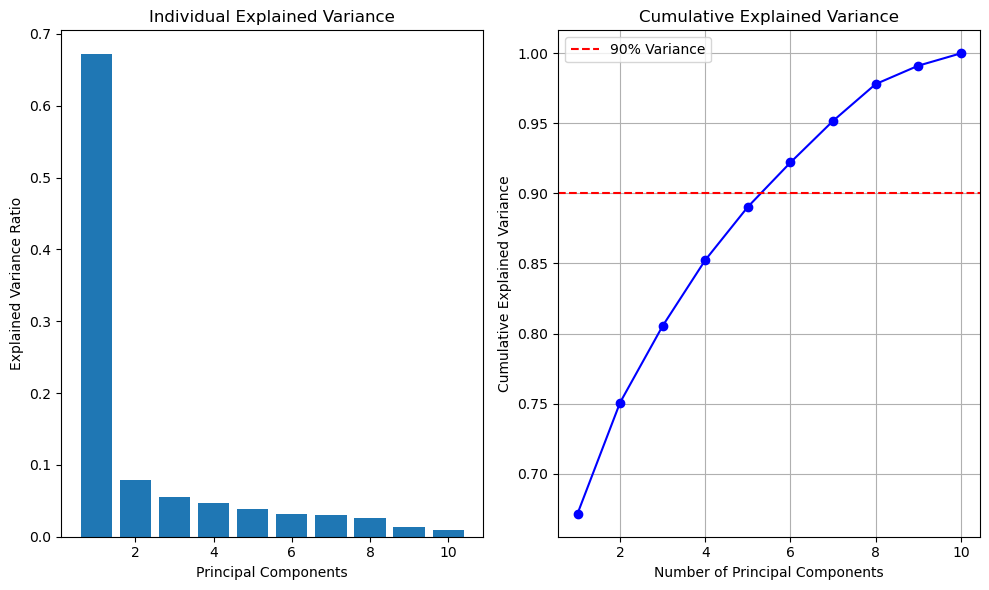

In [107]:
# Scree plot
plt.figure(figsize=(8, 6))

# Plot individual explained variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title('Individual Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

# Plot cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

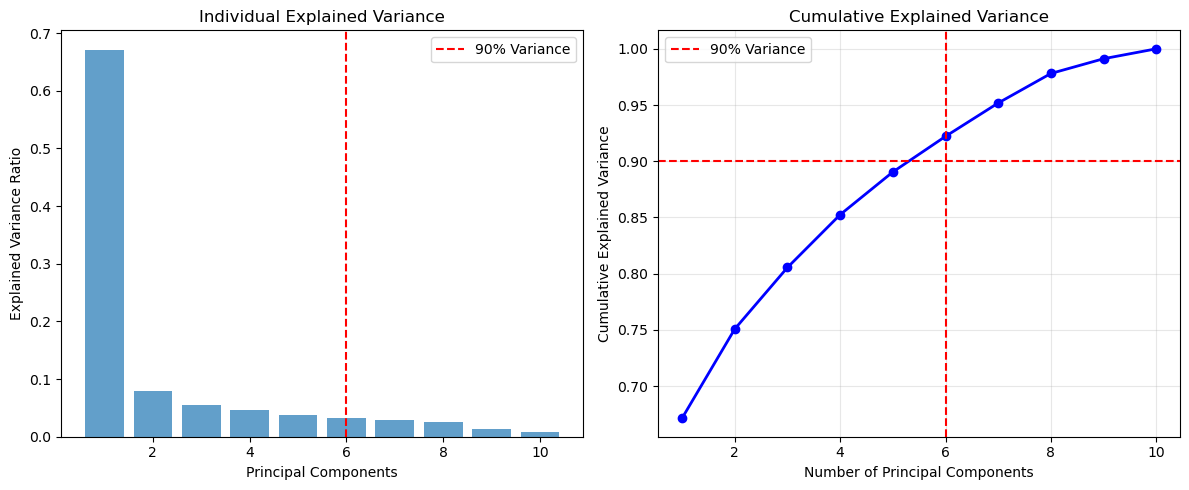

In [112]:
# Create scree plot
plt.figure(figsize=(12, 5))

# Plot 1: Individual explained variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7)
plt.axvline(x=n_components_90, color='r', linestyle='--', label=f'{threshold*100:.0f}% Variance')
plt.title('Individual Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()

# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold*100:.0f}% Variance')
plt.axvline(x=n_components_90, color='r', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



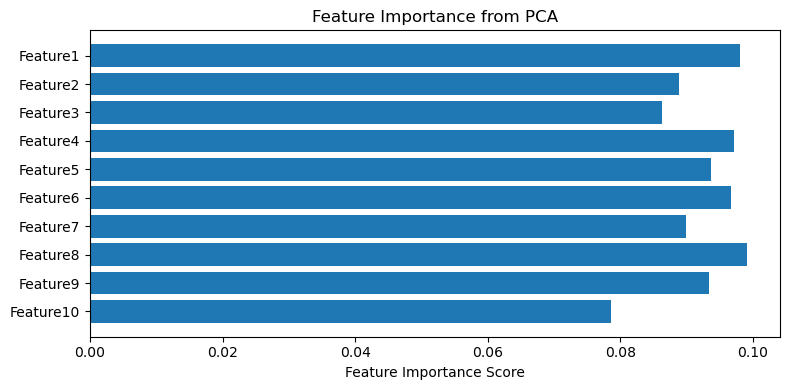

In [114]:
# Create feature importance plot
plt.figure(figsize=(8, 4))
features = dataset2.columns
y_pos = np.arange(len(features))

plt.barh(y_pos, feature_importance)
plt.yticks(y_pos, features)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance from PCA')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

In [111]:
print("\n" + "="*60)
print("PCA ANALYSIS SUMMARY")
print("="*60)
print(f"Original number of features: {dataset2.shape[1]}")
print(f"Number of components for 90% variance: {n_components_90}")
print(f"Variance retained: {cumulative_variance[n_components_90-1]:.3f}")
print(f"Data reduction: {(1 - n_components_90/dataset2.shape[1])*100:.1f}%")
print(f"\nTop {len(top_6_features)} most important features:")
for i, (feat, score) in enumerate(zip(top_6_features, top_6_scores), 1):
    print(f"  {i}. {feat}: {score:.4f}")
    


PCA ANALYSIS SUMMARY
Original number of features: 10
Number of components for 90% variance: 6
Variance retained: 0.922
Data reduction: 40.0%

Top 6 most important features:
  1. Feature8: 0.0992
  2. Feature1: 0.0980
  3. Feature4: 0.0972
  4. Feature6: 0.0968
  5. Feature5: 0.0937
  6. Feature9: 0.0935
